# Week 8 Final Project
## Autonomous Cyber Threat Intelligence Agent

This project implements an autonomous multi agent AI system capable of analyzing cybersecurity vulnerabilities and estimating their severity.

The system combines several modern AI engineering techniques:

• Retrieval Augmented Generation (RAG)  
• Large Language Model reasoning  
• Multi agent orchestration  
• Ensemble prediction strategies  
• Autonomous planning agents  

The architecture follows an agent based workflow where specialized agents collaborate to analyze vulnerability descriptions, retrieve similar threats from a vector database, estimate severity scores, and determine the overall risk level.

A Chroma vector database stores a dataset of synthetic vulnerability records that enable the RAG agent to retrieve contextual information during analysis. An ensemble agent combines predictions from a RAG based estimator and an LLM based reasoning agent, while a planning agent orchestrates the workflow and determines the final threat classification. The system also includes evaluation metrics, logging for agent observability, and a Gradio interface that allows users to interactively analyze vulnerabilities.

## Dataset

The dataset used for this project is hosted externally to keep the repository lightweight.

Dataset:  
https://huggingface.co/datasets/stevemwas/cyber-vulnerabilities

Download the dataset and place the file:

community-contributions/steve/cyber_vulnerabilities_500.jsonl

before running the notebook.




In [31]:
# Environment and API setup

import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HF_API_KEY = os.getenv("HUGGING_FACE_TOKEN")

print("OpenAI Key Loaded:", OPENAI_API_KEY is not None)
print("HuggingFace Token Loaded:", HF_API_KEY is not None)

OpenAI Key Loaded: True
HuggingFace Token Loaded: True


In [ ]:
# Core system libraries
import os
import json
import numpy as np
import pandas as pd
from datasets import Dataset
import chromadb
from openai import OpenAI
import gradio as gr

print("Libraries loaded successfully")

Libraries loaded successfully


In [11]:
# Initialize OpenAI client

client = OpenAI(api_key=OPENAI_API_KEY)

print("OpenAI client initialized successfully")

OpenAI client initialized successfully


In [12]:
# Test OpenAI connection with a simple model call

response = client.chat.completions.create(
    model="gpt-5-mini",
    messages=[
        {"role": "user", "content": "In one sentence explain what a cybersecurity vulnerability is."}
    ]
)

print(response.choices[0].message.content)

A cybersecurity vulnerability is a weakness in software, hardware, configuration, or procedures that can be exploited by attackers to gain unauthorized access, disrupt services, or compromise confidentiality, integrity, or availability.


In [33]:
# Load cybersecurity dataset from JSONL file

from datasets import load_dataset

dataset = load_dataset(
    "stevemwas/cyber-vulnerabilities",
    split="train"
)

df = dataset.to_pandas()

# Reset dataframe index
df = df.reset_index(drop=True)

print("Dataset size:", len(df))
df.head()


Dataset size: 500


,description,severity,category
0,SQL injection vulnerability in the user profil...,5.4,Path Traversal
1,Buffer overflow in the admin dashboard that co...,6.5,XSS
2,Remote code execution vulnerability in the pay...,8.2,Injection
3,Cross-site scripting vulnerability in the sess...,5.2,Configuration
4,Directory traversal vulnerability in the user ...,8.3,Authentication


In [14]:
# Initialize Chroma vector database

chroma_client = chromadb.Client()

try:
    chroma_client.delete_collection(name="cyber_threats")
    print("Old collection deleted")
except:
    print("No existing collection to delete")

collection = chroma_client.create_collection(name="cyber_threats")

print("New vector database created")

No existing collection to delete
New vector database created


In [15]:
# Function to generate embeddings using OpenAI

def get_embedding(text):

    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )

    return response.data[0].embedding

In [16]:
# Insert dataset into Chroma vector database
from tqdm import tqdm

for i, row in tqdm(df.iterrows(), total=len(df)):

    embedding = get_embedding(row["description"])

    collection.add(
        ids=[str(i)],
        documents=[row["description"]],
        embeddings=[embedding],
        metadatas=[{
            "severity": float(row["severity"]),
            "category": row["category"]
        }]
    )

100%|██████████| 500/500 [03:25<00:00,  2.43it/s]


In [17]:
# Function to retrieve similar vulnerabilities from the vector database

def retrieve_similar_threats(query, n_results=3):

    query_embedding = get_embedding(query)

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=n_results
    )

    return results

In [18]:
# Setup logging for the agent system

import logging
import sys

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
    handlers=[logging.StreamHandler(sys.stdout)]
)

logger = logging.getLogger()

print("Logging initialized")

Logging initialized


In [19]:
# RAG Agent with logging

class RAGAgent:

    def estimate_severity(self, description):

        logger.info("RAGAgent retrieving similar vulnerabilities")

        results = retrieve_similar_threats(description)

        severities = [
            metadata["severity"]
            for metadata in results["metadatas"][0]
        ]

        estimated_severity = np.mean(severities)

        logger.info(f"RAGAgent estimated severity: {estimated_severity:.2f}")

        return estimated_severity

In [20]:
# LLM Agent with logging

class LLMThreatAgent:

    def estimate_severity(self, description):

        logger.info("LLMThreatAgent analyzing vulnerability")

        prompt = f"""
You are a cybersecurity expert.

Estimate the severity score (0-10) of the following vulnerability.

Vulnerability:
{description}

Respond with ONLY the number.
"""

        response = client.chat.completions.create(
            model="gpt-5-mini",
            messages=[
                {"role": "user", "content": prompt}
            ]
        )

        result = response.choices[0].message.content.strip()

        try:
            severity = float(result)
        except:
            severity = 5.0

        logger.info(f"LLMThreatAgent estimated severity: {severity:.2f}")

        return severity

In [21]:
# Ensemble Agent with logging

class EnsembleAgent:

    def __init__(self):
        self.rag_agent = RAGAgent()
        self.llm_agent = LLMThreatAgent()

    def estimate_severity(self, description):

        logger.info("EnsembleAgent combining predictions")

        rag_score = self.rag_agent.estimate_severity(description)
        llm_score = self.llm_agent.estimate_severity(description)

        # Weighted combination
        final_score = (0.6 * rag_score) + (0.4 * llm_score)

        logger.info(f"EnsembleAgent final severity score: {final_score:.2f}")

        return {
            "rag_score": rag_score,
            "llm_score": llm_score,
            "final_score": final_score
        }

In [22]:
# Planning Agent with logging

class PlanningAgent:

    def __init__(self):
        self.ensemble_agent = EnsembleAgent()

    def analyze_threat(self, description):

        logger.info("PlanningAgent received threat description")

        result = self.ensemble_agent.estimate_severity(description)

        severity = result["final_score"]

        # Determine risk level
        if severity >= 9:
            risk_level = "CRITICAL"
        elif severity >= 7:
            risk_level = "HIGH"
        elif severity >= 4:
            risk_level = "MEDIUM"
        else:
            risk_level = "LOW"

        logger.info(f"PlanningAgent classified risk level: {risk_level}")

        return {
            "description": description,
            "rag_score": result["rag_score"],
            "llm_score": result["llm_score"],
            "final_score": severity,
            "risk_level": risk_level
        }

In [23]:
# Alert Agent for notifying about critical threats

class AlertAgent:

    def send_alert(self, analysis):

        risk = analysis["risk_level"]
        score = analysis["final_score"]
        description = analysis["description"]

        if risk in ["CRITICAL", "HIGH"]:

            message = f"""
***SECURITY ALERT***

Threat Detected:
{description}

Risk Level: {risk}
Severity Score: {score:.2f}

Immediate investigation recommended.
"""
        else:

            message = f"""
Threat analyzed.

Risk Level: {risk}
Severity Score: {score:.2f}
"""

        return message

In [24]:
# Main framework orchestrating the agents

class ThreatAgentFramework:

    def __init__(self):

        self.planner = PlanningAgent()
        self.alert_agent = AlertAgent()

        # memory of analyzed threats
        self.memory = []

    def run(self, threat_description):

        analysis = self.planner.analyze_threat(threat_description)

        self.memory.append(analysis)

        alert_message = self.alert_agent.send_alert(analysis)

        return {
            "analysis": analysis,
            "alert": alert_message
        }

In [25]:
# Synthetic cybersecurity vulnerability generator

def generate_vulnerabilities(batch_size=50):

    prompt = f"""
Generate {batch_size} realistic cybersecurity vulnerability records.

Each record must contain:
- description
- severity score between 1 and 10
- category

Respond ONLY in JSON format like this:

[
  {{
    "description": "example vulnerability description",
    "severity": 7.4,
    "category": "Injection"
  }}
]
"""

    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )

    content = response.choices[0].message.content

    data = json.loads(content)

    return data

In [26]:
# Evaluate the agent against real dataset severities

evaluation_results = []
planner = PlanningAgent()

sample_df = df.sample(50)

for _, row in sample_df.iterrows():

    description = row["description"]
    true_severity = float(row["severity"])

    predicted = planner.analyze_threat(description)["final_score"]

    evaluation_results.append({
        "description": description,
        "true_severity": true_severity,
        "predicted_severity": predicted
    })

eval_df = pd.DataFrame(evaluation_results)

eval_df.head()

[15:27:08] [INFO] PlanningAgent received threat description
[15:27:08] [INFO] EnsembleAgent combining predictions
[15:27:08] [INFO] RAGAgent retrieving similar vulnerabilities
[15:27:08] [INFO] HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
[15:27:08] [INFO] RAGAgent estimated severity: 5.93
[15:27:08] [INFO] LLMThreatAgent analyzing vulnerability
[15:27:12] [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[15:27:12] [INFO] LLMThreatAgent estimated severity: 10.00
[15:27:12] [INFO] EnsembleAgent final severity score: 7.56
[15:27:12] [INFO] PlanningAgent classified risk level: HIGH
[15:27:12] [INFO] PlanningAgent received threat description
[15:27:12] [INFO] EnsembleAgent combining predictions
[15:27:12] [INFO] RAGAgent retrieving similar vulnerabilities
[15:27:12] [INFO] HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
[15:27:12] [INFO] RAGAgent estimated severity: 7.10
[15:27:12] [INFO] LLMThreat

,description,true_severity,predicted_severity
0,Authentication bypass vulnerability in the use...,8.3,7.56
1,Improper access control in the REST API gatewa...,8.6,7.46
2,Improper access control in the REST API gatewa...,5.3,7.86
3,Authentication bypass vulnerability in the aut...,4.9,7.86
4,Insecure deserialization vulnerability in the ...,4.0,6.98


In [27]:
# Compute Mean Absolute Error

eval_df["error"] = abs(
    eval_df["true_severity"] - eval_df["predicted_severity"]
)

mae = eval_df["error"].mean()

print("Mean Absolute Error (MAE):", round(mae, 3))

Mean Absolute Error (MAE): 1.567


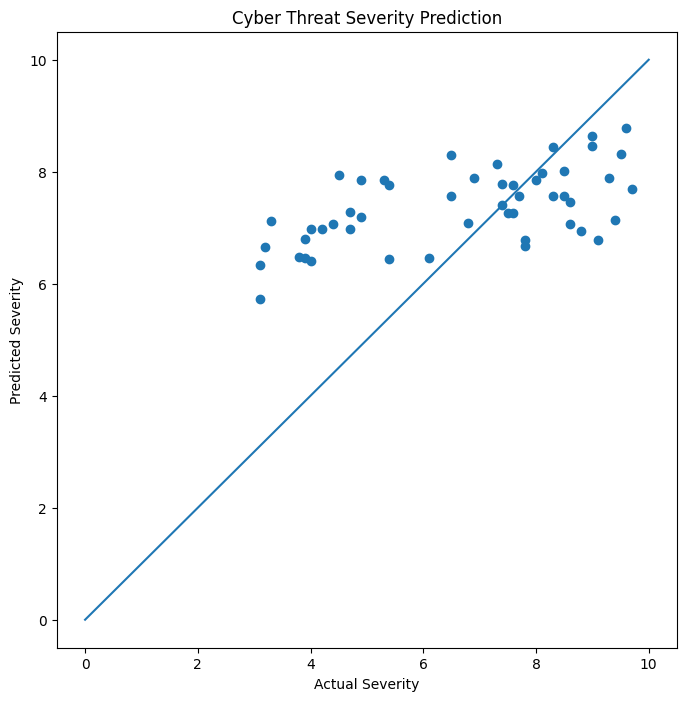

In [28]:
# Visualization of prediction accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    eval_df["true_severity"],
    eval_df["predicted_severity"]
)

plt.xlabel("Actual Severity")
plt.ylabel("Predicted Severity")

plt.title("Cyber Threat Severity Prediction")

# Ideal prediction line
plt.plot([0,10],[0,10])

plt.show()

In [ ]:
# Create UI function


framework = ThreatAgentFramework()

import gradio as gr

def analyze_threat_ui(description):

    result = framework.run(description)

    analysis = result["analysis"]
    alert = result["alert"]

    output = f"""
Threat Description:
{analysis["description"]}

RAG Score: {analysis["rag_score"]:.2f}
LLM Score: {analysis["llm_score"]:.2f}

Final Severity Score: {analysis["final_score"]:.2f}
Risk Level: {analysis["risk_level"]}

{alert}
"""

    return output


with gr.Blocks(title="Autonomous Cyber Threat Intelligence Agent") as ui:

    gr.Markdown(
        """
        # Autonomous Cyber Threat Intelligence Agent
        
        Analyze cybersecurity vulnerabilities using a multi-agent AI system with
        **RAG retrieval, LLM reasoning, and ensemble prediction**.
        """
    )

    # Input
    description_input = gr.Textbox(
        label="Enter Cybersecurity Vulnerability Description",
        placeholder="Example: SQL injection vulnerability in login API",
        lines=4
    )

    # Output
    output_box = gr.Textbox(
        label="Threat Analysis",
        lines=12
    )

    # Buttons row
    with gr.Row():
        submit_btn = gr.Button("Analyze Threat")
        clear_btn = gr.Button("Clear")

    # Button actions
    submit_btn.click(
        analyze_threat_ui,
        inputs=description_input,
        outputs=output_box
    )

    clear_btn.click(
        lambda: ("", ""),
        inputs=[],
        outputs=[description_input, output_box]
    )

ui.launch()

* Running on local URL:  http://127.0.0.1:7863
[15:42:53] [INFO] HTTP Request: GET http://127.0.0.1:7863/gradio_api/startup-events "HTTP/1.1 200 OK"
[15:42:53] [INFO] HTTP Request: HEAD http://127.0.0.1:7863/ "HTTP/1.1 200 OK"
* To create a public link, set `share=True` in `launch()`.


[15:42:53] [INFO] HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
[15:43:39] [INFO] PlanningAgent received threat description
[15:43:39] [INFO] EnsembleAgent combining predictions
[15:43:39] [INFO] RAGAgent retrieving similar vulnerabilities
[15:43:41] [INFO] HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
[15:43:41] [INFO] RAGAgent estimated severity: 8.10
[15:43:41] [INFO] LLMThreatAgent analyzing vulnerability
[15:43:46] [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[15:43:46] [INFO] LLMThreatAgent estimated severity: 10.00
[15:43:46] [INFO] EnsembleAgent final severity score: 8.86
[15:43:46] [INFO] PlanningAgent classified risk level: HIGH
